Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8786 - loss: 0.4357
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9644 - loss: 0.1204
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9777 - loss: 0.0749
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9839 - loss: 0.0538
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9871 - loss: 0.0413
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9733 - loss: 0.0938
Test Accuracy: 0.9757999777793884
Enter image path (example: two_digits.png): digit 73.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Predicted Number = 6 7


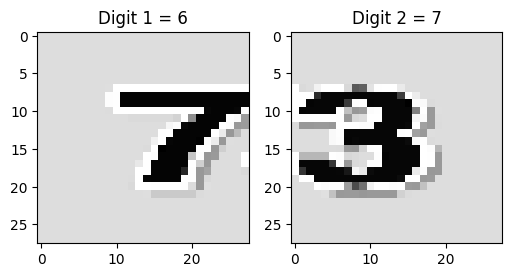

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import cv2
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


x_train = x_train / 255.0
x_test = x_test / 255.0


model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)


test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


img_path = input("Enter image path (example: two_digits.png): ")
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: image not found.")
    exit()


img = cv2.resize(img, (56, 28))
img = img / 255.0


digit1 = img[:, :28]
digit2 = img[:, 28:]

digit1_input = digit1.reshape(1, 28, 28)
digit2_input = digit2.reshape(1, 28, 28)

pred1 = model.predict(digit1_input)
pred2 = model.predict(digit2_input)

digit1_pred = pred1.argmax()
digit2_pred = pred2.argmax()

print("Predicted Number =", digit1_pred, digit2_pred)


plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(digit1, cmap='gray')
plt.title("Digit 1 = " + str(digit1_pred))

plt.subplot(1,2,2)
plt.imshow(digit2, cmap='gray')
plt.title("Digit 2 = " + str(digit2_pred))

plt.show()
